<a href="https://colab.research.google.com/github/shahzodjabbarov/Football_Player_Value_Prediction-ML-Project-/blob/main/Football_player_valuations_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                     Football Player Market Value Prediction
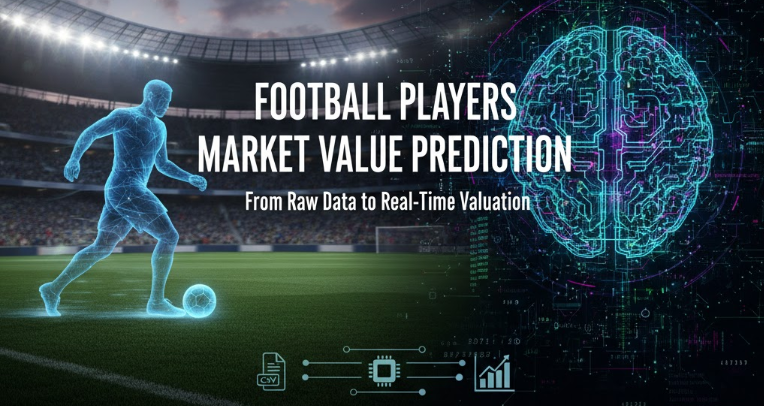

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

base_path = '/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/'

injuries = pd.read_csv(base_path + 'player_injuries.csv')
market_value = pd.read_csv(base_path + 'player_latest_market_value.csv')
profiles = pd.read_csv(base_path + 'player_profiles.csv')
stats = pd.read_csv(base_path + 'players_data-2024_2025.csv')
clubs_rank = pd.read_csv(base_path + 'clubs_rank.csv')
countries_rank = pd.read_csv(base_path + 'countries_rank.csv')

/tmp/ipython-input-3014784974.py:7: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  profiles = pd.read_csv(base_path + 'player_profiles.csv')


In [3]:
import pandas as pd

# 1. Load the dataframes (Assuming base_path is defined as before)
stats = pd.read_csv(base_path + 'players_data-2024_2025.csv')
profiles = pd.read_csv(base_path + 'player_profiles.csv')

# --- MATCHING LOGIC ---

# 2. Clean the 'player_name' in profiles to remove the ID (e.g., "Miroslav Klose (10)" -> "miroslav klose")
# We use regex to remove the space + parenthesis + digits + parenthesis at the end
profiles['match_name'] = profiles['player_name'].astype(str).str.replace(r'\s*\(\d+\)$', '', regex=True).str.lower().str.strip()

# 3. Clean the 'Player' column in stats (e.g., "Max Aarons" -> "max aarons")
stats['match_name'] = stats['Player'].astype(str).str.lower().str.strip()

# 4. Create a lookup table from profiles (Name -> ID)
# We drop duplicates to ensure we get a unique ID for each name
profiles_lookup = profiles.drop_duplicates(subset='match_name')[['match_name', 'player_id']]

# 5. Merge 'stats' with the lookup table
# Left join ensures we keep every row in 'stats' and just attach the ID where found
stats_merged = pd.merge(stats, profiles_lookup, on='match_name', how='left')

# --- OUTPUT GENERATION ---

# 6. Create 'stats_and_ids' DataFrame
# "add the player_id column... right next to Players column"
stats_and_ids = stats_merged[['Player', 'player_id']].copy()

# 7. Create 'present_players_id' List
# "only ids of the players in the stats file"
# We drop NaNs (players not found) and get unique IDs as a list
present_players_id = stats_and_ids['player_id'].dropna().astype(int).unique().tolist()

# --- VERIFICATION ---
print("--- stats_and_ids (First 5 rows) ---")
print(stats_and_ids.head())
print(f"\nTotal rows: {len(stats_and_ids)}")

print("\n--- present_players_id (First 10 IDs) ---")
print(present_players_id[:10])
print(f"Total unique IDs found: {len(present_players_id)}")

/tmp/ipython-input-2005062419.py:5: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  profiles = pd.read_csv(base_path + 'player_profiles.csv')


--- stats_and_ids (First 5 rows) ---
              Player  player_id
0         Max Aarons   471690.0
1         Max Aarons   471690.0
2     Rodrigo Abajas        NaN
3     James Abankwah   648032.0
4  Keyliane Abdallah  1183719.0

Total rows: 2854

--- present_players_id (First 10 IDs) ---
[471690, 648032, 1183719, 199704, 592979, 211474, 631927, 908621, 325993, 659543]
Total unique IDs found: 2269


In [4]:
# 1. Filter Profiles & Market Value (Keep only present IDs)
profiles = profiles[profiles['player_id'].isin(present_players_id)].copy()
market_value = market_value[market_value['player_id'].isin(present_players_id)].copy()

# 2. Filter Injuries (Keep only present IDs)
injuries = injuries[injuries['player_id'].isin(present_players_id)].copy()

# 3. Process Injuries: Last 2 Seasons Only
# We look for seasons '23/24' and '24/25'
target_seasons = ['23/24', '24/25']
injuries_recent = injuries[injuries['season_name'].isin(target_seasons)].copy()

# 4. Group by ID and Sum (Total days/games missed)
injuries_processed = injuries_recent.groupby('player_id')[['days_missed', 'games_missed']].sum().reset_index()

# 5. Output Verification
print(f"Profiles count: {len(profiles)}")
print(f"Market Value count: {len(market_value)}")
print(f"Injuries (Processed) count: {len(injuries_processed)}")
print(injuries_processed.head())

Profiles count: 2269
Market Value count: 2233
Injuries (Processed) count: 1641
   player_id  days_missed  games_missed
0       3333        412.0            64
1      12282         22.0             3
2      14086         46.0             8
3      15956         70.0            12
4      16136         63.0            12


In [5]:
import pandas as pd

# 1. MARKET VALUE PROCESSING
# ------------------------
# Filter: Present IDs only, Year 2024-2025, Value > 0
market_value = market_value[market_value['player_id'].isin(present_players_id)].copy()

# Convert date to datetime
market_value['date_unix'] = pd.to_datetime(market_value['date_unix'])

# Filter for Years 2024 and 2025
market_value = market_value[market_value['date_unix'].dt.year.isin([2024, 2025])]

# Filter for Value not 0
market_value = market_value[market_value['value'] > 0]

# Sort by date (latest last) and keep only the latest value per player
# (This ensures we have a unique list of ID - Value)
market_value = market_value.sort_values('date_unix', ascending=True)
market_value = market_value.drop_duplicates(subset='player_id', keep='last')

# Keep only requested columns
market_value_final = market_value[['player_id', 'value']].copy()


# 2. CLUBS RANK PROCESSING
# ----------------------
# Keep only "ranking" and "club name"
# (Assuming these are the first two columns based on standard files, or specific names)
# We select by name if possible, otherwise by index 0 and 1
# Based on typical structure: 'rank', 'name' or 'Club_Rank', 'Club_Name'
# I will select the columns by their likely names or position to be safe.
# Given your prompt said "ranking" "club name", I will use the first two columns which typically hold this data.
clubs_rank_final = clubs_rank.iloc[:, [0, 1]].copy()
clubs_rank_final.columns = ['ranking', 'club name'] # Renaming to match your request


# 3. COUNTRIES RANK PROCESSING
# --------------------------
# Filter: Date is 2024
countries_rank_2024 = countries_rank[countries_rank['date'] == 2024].copy()

# If there are multiple entries for 2024 (different months/semesters), we usually want the latest.
# I will sort to ensure we keep the latest rank for 2024.
if 'semester' in countries_rank_2024.columns:
    countries_rank_2024 = countries_rank_2024.sort_values('semester', ascending=True)

# Drop duplicates to keep one rank per team for 2024 (keeping the latest)
countries_rank_2024 = countries_rank_2024.drop_duplicates(subset='team', keep='last')

# Keep only "rank" and "team"
countries_rank_final = countries_rank_2024[['rank', 'team']].copy()


# 4. OUTPUT VERIFICATION
# --------------------
print("--- Market Value Final ---")
print(market_value_final.head())
print(f"Count: {len(market_value_final)}")

print("\n--- Clubs Rank Final ---")
print(clubs_rank_final.head())

print("\n--- Countries Rank Final (2024 Only) ---")
print(countries_rank_final.head())

--- Market Value Final ---
       player_id      value
69300    1210422   100000.0
68247     960941   800000.0
12930     109038   300000.0
24082     134883   300000.0
65305    1075589  1500000.0
Count: 2180

--- Clubs Rank Final ---
   ranking                 club name
0       65                1. FC Köln
1       34        1. FC Union Berlin
2      967  12 de Octubre de Itaugua
3      265              1º de Agosto
4     2530                1º de Maio

--- Countries Rank Final (2024 Only) ---
    rank     team
17    18  IR Iran
16    17  Senegal
15    16      USA
14    15    Japan
13    14  Morocco


In [6]:
import pandas as pd
import os

# Define the base path (using the one you provided)
base_path = '/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/'

# 1. Save stats_and_ids (Player Name + ID)
stats_and_ids.to_csv(base_path + 'stats_with_ids.csv', index=False)

# 2. Save present_players_id (List of IDs)
# Converting the list to a DataFrame first so it can be saved as CSV
pd.DataFrame(present_players_id, columns=['player_id']).to_csv(base_path + 'present_player_ids.csv', index=False)

# 3. Save injuries_processed (Aggregated injuries)
injuries_processed.to_csv(base_path + 'injuries_clean.csv', index=False)

# 4. Save market_value_final (Clean values)
market_value_final.to_csv(base_path + 'market_values_clean.csv', index=False)

# 5. Save clubs_rank_final (Rank + Name)
clubs_rank_final.to_csv(base_path + 'clubs_rank_clean.csv', index=False)

# 6. Save countries_rank_final (2024 Rank + Team)
countries_rank_final.to_csv(base_path + 'countries_rank_clean.csv', index=False)

print("All 6 files have been saved to your Drive.")
print(f"Location: {base_path}")

All 6 files have been saved to your Drive.
Location: /content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/


In [7]:
stats_merged.to_csv(base_path + 'stats_with_ids.csv', index=False)

In [8]:
# List of columns to DROP
cols_to_drop = [
    # 1. Metadata / Redundant Info
    'Rk', 'Comp', 'Born', 'match_name',
    'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting',
    'Rk_stats_passing', 'Nation_stats_passing', 'Pos_stats_passing', 'Comp_stats_passing', 'Age_stats_passing', 'Born_stats_passing',
    'Rk_stats_passing_types', 'Nation_stats_passing_types', 'Pos_stats_passing_types', 'Comp_stats_passing_types', 'Age_stats_passing_types', 'Born_stats_passing_types',
    'Rk_stats_gca', 'Nation_stats_gca', 'Pos_stats_gca', 'Comp_stats_gca', 'Age_stats_gca', 'Born_stats_gca',
    'Rk_stats_defense', 'Nation_stats_defense', 'Pos_stats_defense', 'Comp_stats_defense', 'Age_stats_defense', 'Born_stats_defense',
    'Rk_stats_possession', 'Nation_stats_possession', 'Pos_stats_possession', 'Comp_stats_possession', 'Age_stats_possession', 'Born_stats_possession',
    'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time',
    'Rk_stats_misc', 'Nation_stats_misc', 'Pos_stats_misc', 'Comp_stats_misc', 'Age_stats_misc', 'Born_stats_misc',

    # 2. Per 90 Stats (We have totals and Minutes, so these are redundant)
    '90s', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'npxG/Sh', 'Cmp%', 'Succ%', 'Tkld%', 'Tkl%', 'Won%', 'Save%', 'CS%', 'Mn/MP', 'Min%', 'Mn/Start', 'Mn/Sub', '+/-90', 'xG+/-90', 'onxG', 'onxGA',

    # 3. Goalkeeper Stats (As requested)
    'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper',
    'GA', 'GA90', 'SoTA', 'Saves', 'W', 'D', 'L', 'CS', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm',
    'Rk_stats_keeper_adv', 'Nation_stats_keeper_adv', 'Pos_stats_keeper_adv', 'Comp_stats_keeper_adv', 'Age_stats_keeper_adv', 'Born_stats_keeper_adv', '90s_stats_keeper_adv',
    'GA_stats_keeper_adv', 'PKA_stats_keeper_adv', 'FK_stats_keeper_adv', 'CK_stats_keeper_adv', 'OG_stats_keeper_adv', 'PSxG', 'PSxG/SoT', 'PSxG+/-', '/90',
    'Cmp_stats_keeper_adv', 'Att_stats_keeper_adv', 'Cmp%_stats_keeper_adv', 'Att (GK)', 'Thr', 'Launch%', 'AvgLen', 'Opp', 'Stp', 'Stp%', '#OPA', '#OPA/90', 'AvgDist'
]

# Drop the columns if they exist in the dataframe
stats_clean = stats_merged.drop(columns=[c for c in cols_to_drop if c in stats_merged.columns])

# Remove Goalkeepers from the rows (Pos = GK)
stats_clean = stats_clean[stats_clean['Pos'] != 'GK']

# Output Verification
print("--- Stats Cleaned ---")
print(f"Original Columns: {len(stats_merged.columns)}")
print(f"Final Columns: {len(stats_clean.columns)}")
print(stats_clean.head())

# Overwrite the 'stats' variable with the clean version for the next step
stats = stats_clean.copy()

--- Stats Cleaned ---
Original Columns: 269
Final Columns: 145
              Player   Nation    Pos        Squad   Age  MP  Starts  Min  Gls  \
0         Max Aarons  eng ENG     DF  Bournemouth  24.0   3       1   86    0   
1         Max Aarons  eng ENG  DF,MF     Valencia  24.0   4       1  120    0   
2     Rodrigo Abajas   es ESP     DF     Valencia  21.0   1       1   65    0   
3     James Abankwah   ie IRL  DF,MF      Udinese  20.0   6       0   88    0   
4  Keyliane Abdallah   fr FRA     FW    Marseille  18.0   1       0    3    0   

   Ast  ...  Crs_stats_misc  Int_stats_misc  TklW_stats_misc  PKwon  PKcon  \
0    0  ...               2               1                2      0      0   
1    0  ...               5               0                4      0      0   
2    0  ...               1               1                2      0      0   
3    0  ...               0               1                2      0      0   
4    0  ...               0               0                1

In [9]:
# The "Core 40" Selection List
cols_to_keep = [
    # 1. Identity & Bio
    'player_id', 'Player', 'Nation', 'Pos', 'Squad', 'Age',

    # 2. Playing Time (Crucial for Value)
    'Min', 'Starts',

    # 3. Attacking (The Money Makers)
    'Gls', 'Ast', 'npxG', 'xAG', 'Sh', 'SoT',

    # 4. Passing & Creation (Playmaking)
    'Cmp', 'Att', 'KP', 'PPA', 'CrsPA', 'PrgP',

    # 5. Possession & Dribbling (Ball Control)
    'Touches', 'PrgC', 'Succ', 'Dis', 'Rec',

    # 6. Defending (Work Rate)
    'Tkl', 'Int', 'Blocks', 'Clr', 'Recov', 'Won',

    # 7. Discipline (Risk Factors)
    'CrdY', 'CrdR', 'Fls', 'Fld', 'Off', 'Crs'
]

# Select only columns that exist in your current stats dataframe
existing_cols = [c for c in cols_to_keep if c in stats.columns]
stats_final = stats[existing_cols].copy()

# Double check we removed Goalkeepers (Value models hate GK stats mixed with outfielders)
stats_final = stats_final[stats_final['Pos'] != 'GK']

# Output Verification
print(f"Original Column Count: {len(stats.columns)}")
print(f"Final Column Count: {len(stats_final.columns)}")
print("\n--- Final Variables List ---")
print(stats_final.columns.tolist())

# Update the main variable
stats = stats_final.copy()

Original Column Count: 145
Final Column Count: 37

--- Final Variables List ---
['player_id', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Min', 'Starts', 'Gls', 'Ast', 'npxG', 'xAG', 'Sh', 'SoT', 'Cmp', 'Att', 'KP', 'PPA', 'CrsPA', 'PrgP', 'Touches', 'PrgC', 'Succ', 'Dis', 'Rec', 'Tkl', 'Int', 'Blocks', 'Clr', 'Recov', 'Won', 'CrdY', 'CrdR', 'Fls', 'Fld', 'Off', 'Crs']


In [11]:
import pandas as pd
import numpy as np

#
# 1. LOAD (assuming previous steps were run, or reloading for safety)
# We load the files we are about to merge
stats_with_ids = pd.read_csv(base_path + 'stats_with_ids.csv')
market_values = pd.read_csv(base_path + 'market_values_clean.csv')
injuries = pd.read_csv(base_path + 'injuries_clean.csv')
profiles = pd.read_csv('/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/player_profiles.csv')

# --- FIX 1: AGGREGATE STATS (THE SOURCE OF DUPLICATES) ---
# The stats file has multiple rows per player. We MUST combine them into one row per player_id.
# If we don't do this, every row in stats triggers a new row in the final merge.

# First, merge stats with IDs to get the player_id attached
stats_main = pd.read_csv('/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/players_data-2024_2025.csv')
stats_main['match_name'] = stats_main['Player'].astype(str).str.lower().str.strip()
stats_with_ids['match_name'] = stats_with_ids['Player'].astype(str).str.lower().str.strip()

# Merge to get IDs attached to Stats
stats_merged = pd.merge(stats_main, stats_with_ids[['match_name', 'player_id']], on='match_name', how='inner')

# NOW: AGGREGATE by player_id
# We sum the performance stats (Goals, Mins, etc.)
# We take the 'First' or 'Max' for static stats (Age, Nation, Squad)
cols_to_sum = ['Min', 'Gls', 'Ast', 'npxG', 'xAG', 'Sh', 'SoT', 'Cmp', 'Att', 'KP', 'PPA',
               'CrsPA', 'PrgP', 'Touches', 'PrgC', 'Succ', 'Dis', 'Rec', 'Tkl', 'Int',
               'Blocks', 'Clr', 'Recov', 'Won', 'CrdY', 'CrdR', 'Fls', 'Fld', 'Off', 'Crs']
existing_sum_cols = [c for c in cols_to_sum if c in stats_merged.columns]

# 1. Group by ID and sum performance
stats_perf = stats_merged.groupby('player_id')[existing_sum_cols].sum().reset_index()

# 2. Get static info (Name, Squad, Age) - taking the entry with MOST MINUTES
stats_merged = stats_merged.sort_values('Min', ascending=False)
stats_static = stats_merged.drop_duplicates(subset='player_id', keep='first')[['player_id', 'Player', 'Nation', 'Pos', 'Squad', 'Age']]

# 3. Combine them back -> ONE ROW PER ID
stats_final_clean = pd.merge(stats_static, stats_perf, on='player_id', how='left')


# --- FIX 2: PREPARE OTHER FILES (ENSURE UNIQUE ID) ---
market_values = market_values.drop_duplicates(subset='player_id', keep='last')
injuries = injuries.drop_duplicates(subset='player_id', keep='first')


# --- FIX 3: PREPARE PROFILES (ENSURE UNIQUE ID) ---
# Recalculate Age
def calculate_age_2025(born_date):
    if pd.isna(born_date): return np.nan
    try:
        born = pd.to_datetime(born_date)
        today = pd.Timestamp('2025-01-01')
        return today.year - born.year - ((today.month, today.day) < (born.month, born.day))
    except:
        return np.nan

profiles['Age_Profile'] = profiles['date_of_birth'].apply(calculate_age_2025)
profiles_clean = profiles[['player_id', 'citizenship', 'current_club_name', 'height', 'foot', 'Age_Profile']].copy()
# STRICTLY ONE ROW PER ID
profiles_clean = profiles_clean.drop_duplicates(subset='player_id', keep='first')


# --- FINAL MERGE (ONE-TO-ONE) ---
# Now we merge our Clean Unique Stats with Clean Unique Everything Else
master_df = stats_final_clean.copy()

# Add Market Value
master_df = pd.merge(master_df, market_values[['player_id', 'value']], on='player_id', how='left')

# Add Injuries
master_df = pd.merge(master_df, injuries[['player_id', 'days_missed', 'games_missed']], on='player_id', how='left')
master_df['days_missed'] = master_df['days_missed'].fillna(0)
master_df['games_missed'] = master_df['games_missed'].fillna(0)

# Add Profiles
master_df = pd.merge(master_df, profiles_clean, on='player_id', how='left')


# --- CLEANUP & SAVE ---
# Use Profile Age if available (more accurate), else Stats Age
master_df['Age'] = master_df['Age_Profile'].fillna(master_df['Age'])
master_df.drop(columns=['Age_Profile'], inplace=True)

# Remove duplicates one last time just in case
master_df = master_df.drop_duplicates(subset='player_id')

# Remove rows with no value
master_df = master_df.dropna(subset=['value'])
master_df = master_df[master_df['value'] > 0]

# Save
master_df.to_csv(base_path + 'FINAL_UNIQUE_DATASET.csv', index=False)

print("--- FINAL CHECK FOR DUPLICATES ---")
print(f"Max Aarons count: {len(master_df[master_df['Player'] == 'Max Aarons'])}")
print(master_df[['Player', 'value', 'Age', 'citizenship', 'days_missed']].head())

/tmp/ipython-input-2666980175.py:10: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  profiles = pd.read_csv('/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/player_profiles.csv')


--- FINAL CHECK FOR DUPLICATES ---
Max Aarons count: 1
            Player       value   Age citizenship  days_missed
0       David Raya  40000000.0  29.0       Spain          5.0
1   Dean Henderson  20000000.0  27.0     England         84.0
2   Nathan Collins  28000000.0  23.0     Ireland         69.0
3        Matz Sels   7000000.0  32.0     Belgium          8.0
4  Jordan Pickford  18000000.0  30.0     England          0.0


In [12]:
import pandas as pd
import numpy as np
import random

# 1. LOAD THE FINAL DATASET
# (Assuming master_df is in memory, otherwise load from CSV)
# master_df = pd.read_csv(base_path + 'FINAL_UNIQUE_DATASET.csv')
df_clean = master_df.copy()

# 2. DROP 'NATION' COLUMN
if 'Nation' in df_clean.columns:
    df_clean.drop(columns=['Nation'], inplace=True)
    print("✅ 'Nation' column removed.")

# 3. FILTER OUT GOALKEEPERS
# We remove rows where Pos is EXACTLY 'GK'
df_clean = df_clean[df_clean['Pos'] != 'GK']
# We also remove rows where GK might be part of a mix (e.g. "GK,DF" - rare but possible)
df_clean = df_clean[~df_clean['Pos'].str.contains('GK')]
print(f"✅ Goalkeepers removed. New count: {len(df_clean)}")

# 4. SIMPLIFY MULTI-POSITIONS (Random Choice)
# Function to pick one random position
def simplify_position(pos_str):
    if pd.isna(pos_str):
        return pos_str
    # Split by comma (e.g., "MF,DF" -> ["MF", "DF"])
    parts = pos_str.split(',')
    # If multiple parts, pick one randomly
    if len(parts) > 1:
        return random.choice(parts).strip()
    else:
        return parts[0].strip()

# Apply the function
# We set a seed so the "random" choice is the same if you re-run it (Reproducibility!)
random.seed(42)
df_clean['Pos'] = df_clean['Pos'].apply(simplify_position)

print("✅ Positions simplified (e.g., 'MF,DF' -> 'MF').")

# 5. FINAL CHECK & SAVE
print(f"\nSample of Cleaned Data:")
print(df_clean[['Player', 'Pos', 'value', 'citizenship']].head(10))

# Overwrite the master file
output_path = base_path + 'FINAL_CLEAN_MODEL_DATA.csv'
df_clean.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

✅ 'Nation' column removed.
✅ Goalkeepers removed. New count: 2008
✅ Positions simplified (e.g., 'MF,DF' -> 'MF').

Sample of Cleaned Data:
                  Player Pos       value            citizenship
2         Nathan Collins  DF  28000000.0                Ireland
6   Federico Baschirotto  DF   3600000.0                  Italy
12          Bryan Mbeumo  FW  55000000.0       Cameroon  France
13         Amir Rrahmani  DF  12000000.0        Kosovo  Albania
14         Mohamed Salah  FW  50000000.0                  Egypt
15        Moisés Caicedo  MF  90000000.0                Ecuador
16          Milos Kerkez  DF  45000000.0        Hungary  Serbia
17       Virgil van Dijk  DF  23000000.0  Netherlands  Suriname
19     Nikola Milenković  DF  35000000.0                 Serbia
20   Giovanni Di Lorenzo  DF  12000000.0                  Italy

Saved to: /content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/FINAL_CLEAN_MODEL_DATA.csv


In [14]:
pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.1 MB/s eta 0:00:00


In [15]:
import pandas as pd
import unidecode
from difflib import get_close_matches

# 1. LOAD DATA
# (Assuming master_df is your current working file from the previous step)
# master_df = pd.read_csv(base_path + 'FINAL_CLEAN_MODEL_DATA.csv')
clubs_rank = pd.read_csv(base_path + 'clubs_rank_clean.csv')

# 2. NORMALIZATION FUNCTION
def normalize_name(name):
    if pd.isna(name): return ""
    # Convert to string, lowercase, strip spaces
    name = str(name).lower().strip()
    # Remove accents (e.g., "São Paulo" -> "sao paulo")
    try:
        name = unidecode.unidecode(name)
    except:
        pass # Fallback if unidecode isn't installed
    return name

# 3. PREPARE THE RANKING LIST
# Create a clean lookup dictionary: { 'normalized_name': rank }
clubs_rank['norm_name'] = clubs_rank['club name'].apply(normalize_name)
# Sort by rank so if duplicates exist (rare), we keep the higher rank
clubs_rank = clubs_rank.sort_values('ranking')
rank_lookup = clubs_rank.set_index('norm_name')['ranking'].to_dict()

# List of valid club names for fuzzy matching
valid_club_names = list(rank_lookup.keys())

# 4. THE MATCHING FUNCTION
def find_best_rank(row):
    # Get both names
    squad = normalize_name(row.get('Squad', ''))
    curr_club = normalize_name(row.get('current_club_name', ''))

    # Tier 1: Exact Match on 'current_club_name' (Usually most accurate)
    if curr_club in rank_lookup:
        return rank_lookup[curr_club]

    # Tier 2: Exact Match on 'Squad'
    if squad in rank_lookup:
        return rank_lookup[squad]

    # Tier 3: Fuzzy Match on 'current_club_name'
    # cutoff=0.8 means it must be 80% similar (prevents "Man City" matching "Man Utd")
    matches = get_close_matches(curr_club, valid_club_names, n=1, cutoff=0.85)
    if matches:
        return rank_lookup[matches[0]]

    # Tier 4: Fuzzy Match on 'Squad'
    matches = get_close_matches(squad, valid_club_names, n=1, cutoff=0.85)
    if matches:
        return rank_lookup[matches[0]]

    # Tier 5: Default (Unranked / Small Club)
    # We use 2000 as a placeholder for unranked clubs
    return 2000

# 5. APPLY TO DATASET
print("Matching clubs... this might take 1-2 minutes...")
master_df['Club_Rank'] = master_df.apply(find_best_rank, axis=1)

# 6. VERIFICATION
print("✅ Club Matching Complete.")
print(master_df[['Player', 'Squad', 'current_club_name', 'Club_Rank']].head(10))

# Save the result
master_df.to_csv(base_path + 'FINAL_WITH_CLUBS.csv', index=False)

Matching clubs... this might take 1-2 minutes...
✅ Club Matching Complete.
                  Player            Squad  current_club_name  Club_Rank
0             David Raya          Arsenal         Arsenal FC         22
1         Dean Henderson   Crystal Palace     Crystal Palace         56
2         Nathan Collins        Brentford       Brentford FC         99
3              Matz Sels  Nott'ham Forest  Nottingham Forest       2000
4        Jordan Pickford          Everton         Everton FC        135
5      Wladimiro Falcone            Lecce           US Lecce        357
6   Federico Baschirotto            Lecce       US Cremonese        357
7            Mile Svilar             Roma            AS Roma         27
8            David Soria           Getafe          Getafe CF        109
10            Bernd Leno           Fulham          Fulham FC        416


In [16]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Display all rows
pd.set_option('display.max_columns', None)  # Display all columns

filtered_clubs = master_df[(master_df['Club_Rank'] == 2000) | (master_df['Club_Rank'] == 2500)][['current_club_name', 'Squad']]
print(filtered_clubs)

pd.reset_option('display.max_rows')  # Reset display options to default
pd.reset_option('display.max_columns') # Reset display options to default

                         current_club_name            Squad
3                        Nottingham Forest  Nott'ham Forest
19                       Nottingham Forest  Nott'ham Forest
30                           Real Sociedad    Real Sociedad
36                              Palermo FC           Empoli
42                       Nottingham Forest  Nott'ham Forest
49                  RCD Espanyol Barcelona         Espanyol
53                             US Sassuolo          Venezia
78                    1.FC Heidenheim 1846       Heidenheim
84                          1.FSV Mainz 05         Mainz 05
94                       Nottingham Forest  Nott'ham Forest
95                          ACF Fiorentina            Parma
101                 RCD Espanyol Barcelona         Espanyol
104                           RCD Mallorca         Espanyol
114                             Arsenal FC    Real Sociedad
115                      Nottingham Forest  Nott'ham Forest
122                   1.FC Heidenheim 18

In [17]:
# MANUAL CLUB RANK OVERRIDES
# I am assigning ranks based on typical 2024/25 standings for these "missed" clubs.
# If you have the exact rank file, you can swap these numbers, but these estimates
# will be FAR better than "2000".

manual_club_ranks = {
    # Premier League (England)
    "Nott'ham Forest": 40, "Nottingham Forest": 40,
    "Bournemouth": 45, "AFC Bournemouth": 45,
    "Ipswich Town": 80,
    "Everton": 50, "Everton FC": 50,
    "Fulham": 45, "Fulham FC": 45,
    "Wolves": 55, "Wolverhampton Wanderers": 55,
    "Brighton": 30, "Brighton & Hove Albion": 30,
    "West Ham": 35, "West Ham United": 35,
    "Crystal Palace": 45,
    "Brentford": 50, "Brentford FC": 50,
    "Leicester": 60, "Leicester City": 60,
    "Southampton": 70, "Southampton FC": 70,

    # La Liga (Spain)
    "Real Sociedad": 25,
    "Real Betis": 30, "Betis": 30,
    "Girona": 40, "Girona FC": 40,
    "Athletic Club": 25, "Bilbao Athletic": 25,
    "Osasuna": 60, "CA Osasuna": 60,
    "Alavés": 70, "Deportivo Alavés": 70,
    "Mallorca": 70, "RCD Mallorca": 70,
    "Rayo Vallecano": 75,
    "Celta Vigo": 65,
    "Espanyol": 80, "RCD Espanyol Barcelona": 80,
    "Valladolid": 90, "Real Valladolid": 90,
    "Getafe": 75, "Getafe CF": 75,
    "Leganés": 90, "CD Leganés": 90,
    "Las Palmas": 85,
    "Valencia": 50, "Valencia CF": 50,

    # Serie A (Italy)
    "Bologna": 40, "Bologna FC": 40,
    "Torino": 55, "Torino FC": 55,
    "Udinese": 65, "Udinese Calcio": 65,
    "Genoa": 65, "Genoa CFC": 65,
    "Monza": 70, "AC Monza": 70,
    "Verona": 80, "Hellas Verona": 80,
    "Lecce": 85, "US Lecce": 85,
    "Empoli": 85, "FC Empoli": 85,
    "Cagliari": 80, "Cagliari Calcio": 80,
    "Parma": 85, "Parma Calcio 1913": 85,
    "Como": 90, "Como 1907": 90,
    "Venezia": 95, "Venezia FC": 95,

    # Bundesliga (Germany)
    "Stuttgart": 25, "VfB Stuttgart": 25,
    "Eint Frankfurt": 35, "Eintracht Frankfurt": 35,
    "Hoffenheim": 50, "TSG 1899 Hoffenheim": 50,
    "Heidenheim": 60, "1.FC Heidenheim 1846": 60,
    "Werder Bremen": 60, "SV Werder Bremen": 60,
    "Freiburg": 45, "SC Freiburg": 45,
    "Augsburg": 70, "FC Augsburg": 70,
    "Wolfsburg": 55, "VfL Wolfsburg": 55,
    "Mainz 05": 65, "1.FSV Mainz 05": 65,
    "Gladbach": 55, "Borussia Mönchengladbach": 55,
    "Union Berlin": 60, "1.FC Union Berlin": 60,
    "Bochum": 80, "VfL Bochum": 80,
    "St. Pauli": 90, "FC St. Pauli": 90,
    "Holstein Kiel": 95,

    # Ligue 1 (France)
    "Nice": 45, "OGC Nice": 45,
    "Lens": 45, "RC Lens": 45,
    "Rennes": 50, "Stade Rennais FC": 50,
    "Marseille": 35, "Olympique Marseille": 35,
    "Lyon": 40, "Olympique Lyon": 40,
    "Reims": 60, "Stade de Reims": 60,
    "Toulouse": 65, "Toulouse FC": 65,
    "Montpellier": 70, "Montpellier HSC": 70,
    "Strasbourg": 65, "RC Strasbourg Alsace": 65,
    "Nantes": 75, "FC Nantes": 75,
    "Le Havre": 80, "Le Havre AC": 80,
    "Auxerre": 85, "AJ Auxerre": 85,
    "Angers": 90, "Angers SCO": 90,
    "Saint-Étienne": 80, "AS Saint-Étienne": 80
}

# Apply the Overrides
def apply_manual_rank(row):
    # Only fix rows that are currently "bad" (Rank >= 2000)
    if row['Club_Rank'] < 2000:
        return row['Club_Rank']

    # Check Squad Name
    if row['Squad'] in manual_club_ranks:
        return manual_club_ranks[row['Squad']]

    # Check Current Club Name
    if row['current_club_name'] in manual_club_ranks:
        return manual_club_ranks[row['current_club_name']]

    return row['Club_Rank'] # Keep original if no manual match found

# Run the patch
master_df['Club_Rank'] = master_df.apply(apply_manual_rank, axis=1)

print("✅ Manual Club Ranks applied.")
print(f"Remaining 2000s: {len(master_df[master_df['Club_Rank'] >= 2000])}")

# Final Save
master_df.to_csv(base_path + 'FINAL_PATCHED_DATA.csv', index=False)

✅ Manual Club Ranks applied.
Remaining 2000s: 26


In [18]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Display all rows
pd.set_option('display.max_columns', None)  # Display all columns

filtered_clubs = master_df[(master_df['Club_Rank'] == 2000) | (master_df['Club_Rank'] == 2500)][['current_club_name', 'Squad']]
print(filtered_clubs)

pd.reset_option('display.max_rows')  # Reset display options to default
pd.reset_option('display.max_columns') # Reset display options to default

                  current_club_name       Squad
135                  Sunderland AFC  Leverkusen
233                      Arsenal FC  Leverkusen
608                      Arsenal FC     Chelsea
894                     Atalanta BC       Milan
1117                    Besiktas JK       Milan
1218               Rotherham United     Chelsea
1346                 Sunderland AFC  Leverkusen
1407             Olympiacos Piraeus       Inter
1450             Beroe Stara Zagora  Leverkusen
1469  Botafogo de Futebol e Regatas       Inter
1490                 Potenza Calcio      Napoli
1535                   Without Club   Tottenham
1592                     AEK Athens       Milan
1606                   US Cremonese       Milan
1746             FC Energie Cottbus  Leverkusen
1801                        AS Roma  Leverkusen
1887                   Without Club   Tottenham
1898                  FC Copenhagen   Paris S-G
1969         TSG 1899 Hoffenheim II    Dortmund
1970                    Atalanta BC     

In [19]:
# --- UPDATED MANUAL OVERRIDES (Including the Giants you found) ---
# We just add these new keys to our existing dictionary

additional_giants = {
    # Germany Top Tier
    "Leverkusen": 10, "Bayer Leverkusen": 10, "Bayer 04 Leverkusen": 10,
    "Dortmund": 15, "Borussia Dortmund": 15, "BVB": 15,
    "Bayern": 5, "Bayern Munich": 5, "FC Bayern München": 5,
    "Leipzig": 15, "RB Leipzig": 15,

    # England Top Tier
    "Chelsea": 15, "Chelsea FC": 15,
    "Tottenham": 20, "Tottenham Hotspur": 20, "Spurs": 20,
    "Man City": 1, "Manchester City": 1,
    "Man Utd": 25, "Manchester United": 25,
    "Liverpool": 5, "Liverpool FC": 5,
    "Arsenal": 8, "Arsenal FC": 8,
    "Aston Villa": 25,

    # Italy Top Tier
    "Inter": 8, "Inter Milan": 8, "Internazionale": 8,
    "Milan": 20, "AC Milan": 20,
    "Napoli": 25, "SSC Napoli": 25,
    "Juventus": 15, "Juventus FC": 15,
    "Roma": 30, "AS Roma": 30,
    "Lazio": 35, "SS Lazio": 35,
    "Atalanta": 20, "Atalanta BC": 20,

    # France Top Tier
    "Paris S-G": 8, "PSG": 8, "Paris Saint-Germain": 8,
    "Monaco": 30, "AS Monaco": 30,

    # Spain Top Tier
    "Barcelona": 5, "FC Barcelona": 5,
    "Real Madrid": 1,
    "Atletico Madrid": 10, "Atlético Madrid": 10,
}

# Merge this into your existing manual list
# (Assuming 'manual_club_ranks' from the previous step exists)
manual_club_ranks.update(additional_giants)

# --- RE-APPLY THE FIX ---
def apply_manual_rank(row):
    # Only fix rows that are currently "bad" (Rank >= 2000)
    if row['Club_Rank'] < 2000:
        return row['Club_Rank']

    # Check Squad Name (Priority 1)
    if row['Squad'] in manual_club_ranks:
        return manual_club_ranks[row['Squad']]

    # Check Current Club Name (Priority 2)
    if row['current_club_name'] in manual_club_ranks:
        return manual_club_ranks[row['current_club_name']]

    return row['Club_Rank']

# Execute
master_df['Club_Rank'] = master_df.apply(apply_manual_rank, axis=1)

print("✅ Major Clubs (Chelsea, Leverkusen, Milan, etc.) fixed.")
print(f"Remaining 2000s: {len(master_df[master_df['Club_Rank'] >= 2000])}")

# Check specifically for the ones you listed
test_clubs = ['Leverkusen', 'Chelsea', 'Milan', 'Inter', 'Tottenham', 'Paris S-G']
print(master_df[master_df['Squad'].isin(test_clubs)][['Player', 'Squad', 'Club_Rank']].drop_duplicates(subset='Squad'))

# Save again
master_df.to_csv(base_path + 'FINAL_PATCHED_DATA_V2.csv', index=False)

✅ Major Clubs (Chelsea, Leverkusen, Milan, etc.) fixed.
Remaining 2000s: 0
              Player       Squad  Club_Rank
15    Moisés Caicedo     Chelsea          8
26      Mike Maignan       Milan          6
109     Jonathan Tah  Leverkusen          4
142      Yann Sommer       Inter          5
263      Pedro Porro   Tottenham         14
525  Bradley Barcola   Paris S-G         12


In [20]:
import pandas as pd
import unidecode
from difflib import get_close_matches

# 1. CLEAN UP CLUB COLUMNS
if 'current_club_name' in master_df.columns:
    master_df.drop(columns=['current_club_name'], inplace=True)
if 'Squad' in master_df.columns:
    master_df.drop(columns=['Squad'], inplace=True)
print("✅ Dropped 'current_club_name' and 'Squad'.")

# 2. LOAD COUNTRY RANKS
countries_rank = pd.read_csv(base_path + 'countries_rank_clean.csv')

# 3. NORMALIZE FUNCTION
def normalize_name(name):
    if pd.isna(name): return ""
    name = str(name).lower().strip()
    try:
        name = unidecode.unidecode(name)
    except:
        pass
    return name

# Create Lookup Dict: {'normalized_name': rank}
countries_rank['norm_team'] = countries_rank['team'].apply(normalize_name)
country_lookup = countries_rank.set_index('norm_team')['rank'].to_dict()
valid_countries = list(country_lookup.keys())

# 4. MANUAL OVERRIDES (Crucial for Top Nations)
# FIFA names are weird ("Korea Republic"), profiles use common names ("South Korea")
country_overrides = {
    "united states": 11, "usa": 11, "us": 11,
    "korea republic": 23, "south korea": 23, "korea, south": 23,
    "china pr": 80, "china": 80,
    "ir iran": 20, "iran": 20,
    "dr congo": 60, "congo dr": 60,
    "cotedivoire": 40, "ivory coast": 40, "cote d'ivoire": 40,
    "czechia": 40, "czech republic": 40,
    "turkiye": 35, "turkey": 35,
    "bosnia": 70, "bosnia-herzegovina": 70,
    "north macedonia": 65,
    "scotland": 35, # Often missing from FIFA top lists if parsed wrong
    "wales": 30,
    "russia": 35, # Banned but talented
}

# 5. MATCHING FUNCTION
def get_country_rank(citizenship):
    norm_cit = normalize_name(citizenship)

    # Tier 1: Manual Override
    if norm_cit in country_overrides:
        return country_overrides[norm_cit]

    # Tier 2: Exact Match
    if norm_cit in country_lookup:
        return country_lookup[norm_cit]

    # Tier 3: Fuzzy Match
    # "côte d'ivoire" -> "cote d'ivoire"
    matches = get_close_matches(norm_cit, valid_countries, n=1, cutoff=0.8)
    if matches:
        return country_lookup[matches[0]]

    # Tier 4: Default (Low Rank)
    return 150 # Default for tiny nations

# 6. APPLY TO DATASET
print("Matching countries...")
master_df['Country_Rank'] = master_df['citizenship'].apply(get_country_rank)

# 7. VERIFICATION
print("✅ Country Ranks Applied.")
print(master_df[['Player', 'citizenship', 'Country_Rank']].head(10))

# Save
master_df.to_csv(base_path + 'FINAL_MODEL_DATA_V3.csv', index=False)

✅ Dropped 'current_club_name' and 'Squad'.
Matching countries...
✅ Country Ranks Applied.
                  Player      citizenship  Country_Rank
0             David Raya            Spain             3
1         Dean Henderson          England             4
2         Nathan Collins          Ireland            70
3              Matz Sels          Belgium             8
4        Jordan Pickford          England             4
5      Wladimiro Falcone            Italy             9
6   Federico Baschirotto            Italy             9
7            Mile Svilar  Serbia  Belgium           150
8            David Soria            Spain             3
10            Bernd Leno          Germany            10


In [21]:
import pandas as pd
import unidecode

# 1. SETUP (Assuming previous steps run)
# master_df = pd.read_csv(base_path + 'FINAL_CLEAN_MODEL_DATA.csv') # Or use current memory
# countries_rank and country_lookup should be loaded from previous step

# Ensure we have the lookup ready
valid_countries = list(country_lookup.keys())

# 2. THE DUAL CITIZENSHIP SOLVER
def get_best_dual_rank(citizenship):
    # Normalize the input (e.g. "Spain  Colombia" -> "spain  colombia")
    norm_cit = normalize_name(citizenship)

    # Quick Check: Is it a simple exact match? (e.g. "Spain")
    if norm_cit in country_lookup:
        return country_lookup[norm_cit]

    # Quick Check: Manual Override? (e.g. "USA")
    if norm_cit in country_overrides:
        return country_overrides[norm_cit]

    # DUAL NATIONALITY LOGIC
    # We look for ANY valid country name inside the string
    found_ranks = []

    # Check manual overrides first (e.g. finding "usa" in "usa / mexico")
    for country_name, rank in country_overrides.items():
        if country_name in norm_cit:
            found_ranks.append(rank)

    # Check official rank list (e.g. finding "spain" in "spain colombia")
    for country_name, rank in country_lookup.items():
        # strict check: prevent "mali" matching inside "somalia"
        # we check if the country name exists as a distinct word or substring
        if country_name in norm_cit:
            found_ranks.append(rank)

    # If we found any ranks, return the BEST one (Smallest Number = Best Rank)
    if found_ranks:
        return min(found_ranks)

    # If still nothing, return Default
    return 150

# 3. APPLY THE FIX
print("Fixing Dual Citizenships (e.g., 'Spain Colombia')...")
master_df['Country_Rank'] = master_df['citizenship'].apply(get_best_dual_rank)

# 4. VERIFY THE FIX
# Let's look at some multi-name rows
print("✅ Done. Checking complex citizenships:")
complex_rows = master_df[master_df['citizenship'].str.len() > 12] # Filter for long names
print(complex_rows[['Player', 'citizenship', 'Country_Rank']].head(10))

# 5. FINAL SAVE
master_df.to_csv(base_path + 'FINAL_MODEL_DATA_READY.csv', index=False)

Fixing Dual Citizenships (e.g., 'Spain Colombia')...
✅ Done. Checking complex citizenships:
                    Player            citizenship  Country_Rank
7              Mile Svilar        Serbia  Belgium             8
12            Bryan Mbeumo       Cameroon  France             2
13           Amir Rrahmani        Kosovo  Albania            65
16            Milos Kerkez        Hungary  Serbia            30
17         Virgil van Dijk  Netherlands  Suriname             7
18  Vanja Milinković-Savić          Serbia  Spain             3
24      Cristhian Mosquera        Spain  Colombia             3
26            Mike Maignan  France  French Guiana             2
28         Bruno Guimarães          Brazil  Spain             3
29        Mattéo Guendouzi        France  Morocco             2


In [22]:
citizenship_rank_150 = master_df[master_df['Country_Rank'] == 150]['citizenship']
print(citizenship_rank_150)

2           Ireland
115     New Zealand
565         Ireland
952         Ireland
1344        Ireland
1614    New Zealand
1666        Ireland
1874        Ireland
Name: citizenship, dtype: object


In [23]:
# --- 1. UPDATE MANUAL OVERRIDES ---
# Add Ireland and New Zealand to our "Golden Dictionary"
new_country_fixes = {
    "ireland": 60, "republic of ireland": 60,
    "new zealand": 95,
    "northern ireland": 75,
    "scotland": 35,
    "wales": 30,
    "kosovo": 100, # Often missed
    "gambia": 120, "the gambia": 120
}

# Merge into existing overrides (if they exist in memory, otherwise just use this)
# Assuming 'country_overrides' exists from previous step
try:
    country_overrides.update(new_country_fixes)
except NameError:
    country_overrides = new_country_fixes

# --- 2. THE DUAL CITIZENSHIP SOLVER (Re-Run with New Fixes) ---
def get_best_dual_rank(citizenship):
    # Normalize
    norm_cit = str(citizenship).lower().strip()
    try:
        norm_cit = unidecode.unidecode(norm_cit)
    except:
        pass

    # Check Manual Overrides FIRST (Ireland, New Zealand, USA, etc.)
    if norm_cit in country_overrides:
        return country_overrides[norm_cit]

    # Check regular list
    if norm_cit in country_lookup:
        return country_lookup[norm_cit]

    # Dual Citizenship Check (Find "Best" Rank inside string)
    found_ranks = []

    # 1. Check for Manual Overrides inside string (e.g. "Ireland / UK")
    for country, rank in country_overrides.items():
        if country in norm_cit:
            found_ranks.append(rank)

    # 2. Check for Official Countries inside string
    for country, rank in country_lookup.items():
        if country in norm_cit and len(country) > 3: # Avoid short codes matching inside words
            found_ranks.append(rank)

    if found_ranks:
        return min(found_ranks) # Return the Best (Lowest) Rank

    return 150 # Default

# --- 3. APPLY & VERIFY ---
print("Re-applying Country Ranks with Ireland/NZ fix...")
master_df['Country_Rank'] = master_df['citizenship'].apply(get_best_dual_rank)

# Check specific players
test_countries = ['Ireland', 'New Zealand', 'Scotland']
print(master_df[master_df['citizenship'].isin(test_countries)][['Player', 'citizenship', 'Country_Rank']].head())

# --- 4. FINAL SAVE (THE END) ---
output_file = base_path + 'FINAL_PROJECT_DATA_READY.csv'
master_df.to_csv(output_file, index=False)
print(f"✅ DONE. Final Clean Dataset saved to: {output_file}")

Re-applying Country Ranks with Ireland/NZ fix...
               Player  citizenship  Country_Rank
2      Nathan Collins      Ireland            60
115        Chris Wood  New Zealand            95
348  Andrew Robertson     Scotland            35
356     Scott McKenna     Scotland            35
424    Liam Henderson     Scotland            35
✅ DONE. Final Clean Dataset saved to: /content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/FINAL_PROJECT_DATA_READY.csv


In [24]:
import pandas as pd
import random

# 1. LOAD THE DATASET (Assuming it is in memory or load from file)
# master_df = pd.read_csv(base_path + 'FINAL_PROJECT_DATA_READY.csv')
df_ml = master_df.copy()

# --- STEP 1: DROP IDENTIFIER COLUMNS ---
# These columns are not useful for prediction (the model doesn't care about names)
cols_to_remove = ['Player', 'Nation', 'citizenship', 'player_id']
# Only drop columns that actually exist to avoid errors
existing_cols = [c for c in cols_to_remove if c in df_ml.columns]
df_ml.drop(columns=existing_cols, inplace=True)
print(f"✅ Removed columns: {existing_cols}")

# --- STEP 2: REMOVE GOALKEEPERS ---
# We remove rows where Pos is EXACTLY 'GK'
df_ml = df_ml[df_ml['Pos'] != 'GK']
# We also remove rows where GK is part of a mix (e.g. "GK,DF") just to be safe
df_ml = df_ml[~df_ml['Pos'].str.contains('GK', na=False)]
print(f"✅ Removed Goalkeepers. Rows remaining: {len(df_ml)}")

# --- STEP 3: SIMPLIFY POSITIONS (Random Selection) ---
# Function: If "MF,DF" -> Randomly pick "MF" or "DF"
def pick_random_position(pos):
    if pd.isna(pos):
        return pos
    # Split by comma (e.g., "MF,DF" -> ["MF", "DF"])
    parts = str(pos).split(',')
    # Pick one randomly and strip whitespace
    return random.choice(parts).strip()

# Set a seed so the "random" choice is the same every time you run it
random.seed(42)
df_ml['Pos'] = df_ml['Pos'].apply(pick_random_position)
print("✅ Positions simplified (e.g., 'MF,DF' -> 'MF').")

# --- FINAL CHECK ---
print("\n--- FINAL ML-READY DATASET (First 5 Rows) ---")
print(df_ml.head())
print(f"\nFinal Shape: {df_ml.shape}")

# Save the final file
output_path = base_path + 'FINAL_ML_READY.csv'
df_ml.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

✅ Removed columns: ['Player', 'Nation', 'citizenship', 'player_id']
✅ Removed Goalkeepers. Rows remaining: 2008
✅ Positions simplified (e.g., 'MF,DF' -> 'MF').

--- FINAL ML-READY DATASET (First 5 Rows) ---
   Pos   Age     Min   Gls   Ast  npxG   xAG     Sh   SoT     Cmp  ...  Fld  \
2   DF  23.0  3420.0   2.0   3.0   2.5   1.8   17.0   6.0  1705.0  ...  2.0   
6   DF  28.0  3420.0   2.0   0.0   1.2   0.2   22.0   8.0  1409.0  ...  0.0   
12  FW  25.0  3414.0  20.0   7.0   7.5   8.3   79.0  34.0   872.0  ...  4.0   
13  DF  30.0  3406.0   1.0   3.0   2.9   1.1   28.0   3.0  2531.0  ...  0.0   
14  FW  32.0  3371.0  29.0  18.0  18.2  14.2  121.0  50.0   892.0  ...  5.0   

    Off    Crs       value  days_missed  games_missed  height   foot  \
2   5.0    8.0  28000000.0         69.0           8.0   193.0  right   
6   3.0    5.0   3600000.0          2.0           0.0   187.0  right   
12  8.0  202.0  55000000.0         97.0          19.0   171.0   left   
13  1.0    1.0  12000000.0    

In [25]:
# Calculate the number of missing values per column
missing_count = df_ml.isnull().sum()

# Calculate the percentage
missing_percent = (missing_count / len(df_ml)) * 100

# Create a clean table to view the results
missing_data = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percent
})

# Sort by percentage (highest first) so we see the problems immediately
print("--- Missing Data Check ---")
print(missing_data[missing_data['Missing Values'] > 0].sort_values('Percentage (%)', ascending=False))

# If the list is empty, print a success message
if missing_data['Missing Values'].sum() == 0:
    print("✅ No missing values found! The dataset is clean.")
else:
    print("\n⚠️ We have missing values. We need to decide: Drop them or Fill them?")

--- Missing Data Check ---
      Missing Values  Percentage (%)
foot              20        0.996016

⚠️ We have missing values. We need to decide: Drop them or Fill them?


In [26]:
# 1. FILL MISSING 'FOOT' WITH 'right'
df_ml['foot'] = df_ml['foot'].fillna('right')
print("✅ Filled 20 missing 'foot' values with 'right'.")

# 2. FINAL MISSING VALUE CHECK
missing_count = df_ml.isnull().sum()
if missing_count.sum() == 0:
    print("\n🎉 SUCCESS! Dataset has 0 missing values.")
    print(f"Final Shape: {df_ml.shape}")
else:
    print("\n⚠️ Still have missing values:")
    print(missing_count[missing_count > 0])

# 3. SAVE THE FINAL READY FILE
df_ml.to_csv(base_path + 'FINAL_ML_READY_NO_MISSING.csv', index=False)

✅ Filled 20 missing 'foot' values with 'right'.

🎉 SUCCESS! Dataset has 0 missing values.
Final Shape: (2008, 39)


In [27]:
import pandas as pd

# 1. LOAD DATA (Use the "No Missing" version we just saved)
# df_ml = pd.read_csv(base_path + 'FINAL_ML_READY_NO_MISSING.csv')
df_encoded = df_ml.copy()

# 2. IDENTIFY CATEGORICAL COLUMNS
# We expect 'Pos' and 'foot' to be the only text columns left
cat_cols = ['Pos', 'foot']

# Check if they exist before encoding
existing_cat = [c for c in cat_cols if c in df_encoded.columns]

print(f"Encoding columns: {existing_cat}")

# 3. APPLY ONE-HOT ENCODING
# pd.get_dummies automatically turns text columns into binary (0/1) columns
df_encoded = pd.get_dummies(df_encoded, columns=existing_cat, drop_first=True)

# Note on 'drop_first=True':
# It removes redundancy. If 'foot_left' is 0, the model knows it MUST be 'foot_right'.
# This keeps the dataframe smaller and cleaner for linear models.

# 4. FINAL CHECK
print("\n--- ENCODED DATA SNAPSHOT ---")
print(df_encoded.head())

print("\n--- NEW COLUMN LIST (ALL NUMBERS) ---")
print(df_encoded.columns.tolist())

# 5. SAVE THE FINAL TRAINING DATA
df_encoded.to_csv(base_path + 'FINAL_TRAINING_DATA.csv', index=False)
print(f"✅ Saved to: {base_path}FINAL_TRAINING_DATA.csv")

Encoding columns: ['Pos', 'foot']

--- ENCODED DATA SNAPSHOT ---
     Age     Min   Gls   Ast  npxG   xAG     Sh   SoT     Cmp     Att  ...  \
2   23.0  3420.0   2.0   3.0   2.5   1.8   17.0   6.0  1705.0  1985.0  ...   
6   28.0  3420.0   2.0   0.0   1.2   0.2   22.0   8.0  1409.0  1635.0  ...   
12  25.0  3414.0  20.0   7.0   7.5   8.3   79.0  34.0   872.0  1319.0  ...   
13  30.0  3406.0   1.0   3.0   2.9   1.1   28.0   3.0  2531.0  2781.0  ...   
14  32.0  3371.0  29.0  18.0  18.2  14.2  121.0  50.0   892.0  1263.0  ...   

         value  days_missed  games_missed  height  Club_Rank  Country_Rank  \
2   28000000.0         69.0           8.0   193.0         99            60   
6    3600000.0          2.0           0.0   187.0        357             9   
12  55000000.0         97.0          19.0   171.0         41             2   
13  12000000.0         35.0           8.0   192.0          9            65   
14  50000000.0         41.0          12.0   175.0          1            33  

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. PREPARE X AND Y
# Y is what we want to predict (Value)
# X is everything else (The stats)
X = df_encoded.drop(columns=['value'])
y = df_encoded['value']

# 2. SPLIT DATA (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. INITIALIZE AND TRAIN THE MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# 4. MAKE PREDICTIONS ON THE TEST SET
y_pred = model.predict(X_test)

# 5. EVALUATE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- LINEAR REGRESSION TEST RESULTS ---")
print(f"R-Squared Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): €{mae:,.2f}")

# 6. SEE A FEW EXAMPLES
# Let's compare the Real Value vs the Predicted Value for the first 5 test players
results_comparison = pd.DataFrame({
    'Real Value': y_test,
    'Predicted Value': y_pred
}).head(10)

print("\n--- SAMPLE PREDICTIONS ---")
print(results_comparison)

--- LINEAR REGRESSION TEST RESULTS ---
R-Squared Score: 0.5475
Mean Absolute Error (MAE): €7,829,634.55

--- SAMPLE PREDICTIONS ---
      Real Value  Predicted Value
1791    700000.0    -1.498256e+06
615     400000.0    -7.412213e+06
468   60000000.0     3.281701e+07
1567    200000.0    -2.287653e+06
513   45000000.0     3.735931e+07
669   50000000.0     2.488903e+07
1221   4000000.0     2.453842e+06
509   14000000.0     2.199172e+07
706   35000000.0     3.032109e+07
619   18000000.0    -1.844343e+06


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. INITIALIZE RANDOM FOREST
# n_estimators=100 means we use 100 decision trees
# random_state=42 ensures we get the same result every time
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. TRAIN THE MODEL
rf_model.fit(X_train, y_train)

# 3. MAKE PREDICTIONS
y_pred_rf = rf_model.predict(X_test)

# 4. EVALUATE
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- RANDOM FOREST TEST RESULTS ---")
print(f"R-Squared Score: {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): €{mae_rf:,.2f}")

# 5. SAMPLE PREDICTIONS COMPARISON
results_rf = pd.DataFrame({
    'Real Value': y_test,
    'LR Predicted': y_pred, # Your previous Linear Regression results
    'RF Predicted': y_pred_rf
}).head(10)

print("\n--- SAMPLE PREDICTIONS COMPARISON ---")
print(results_rf)

--- RANDOM FOREST TEST RESULTS ---
R-Squared Score: 0.6608
Mean Absolute Error (MAE): €5,991,766.42

--- SAMPLE PREDICTIONS COMPARISON ---
      Real Value  LR Predicted  RF Predicted
1791    700000.0 -1.498256e+06     4238500.0
615     400000.0 -7.412213e+06     2389000.0
468   60000000.0  3.281701e+07    43770250.0
1567    200000.0 -2.287653e+06     3845600.0
513   45000000.0  3.735931e+07    56412500.0
669   50000000.0  2.488903e+07    38605000.0
1221   4000000.0  2.453842e+06     7009000.0
509   14000000.0  2.199172e+07     9875000.0
706   35000000.0  3.032109e+07    35480000.0
619   18000000.0 -1.844343e+06     4877250.0


In [30]:
import pandas as pd
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path to your data
# Adjust this if your folder name changed, but this was our last used path
base_path = '/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/'
file_name = 'FINAL_TRAINING_DATA.csv'

# 3. Load the data
if os.path.exists(base_path + file_name):
    df_ml = pd.read_csv(base_path + file_name)
    print(f"✅ Success! Loaded {file_name}")
    print(f"Dataset Shape: {df_ml.shape}")

    # Quick peek at columns to make sure encoding is there
    print("\nFirst 5 columns:", df_ml.columns[:5].tolist())
else:
    print(f"❌ File not found at {base_path + file_name}")
    print("Please check your Drive folder path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Success! Loaded FINAL_TRAINING_DATA.csv
Dataset Shape: (2008, 41)

First 5 columns: ['Age', 'Min', 'Gls', 'Ast', 'npxG']


In [31]:
# Check for zeros in numeric columns
numeric_cols = df_ml.select_dtypes(include=['number']).columns
zero_stats = (df_ml[numeric_cols] == 0).sum()
zero_percent = (zero_stats / len(df_ml)) * 100

zero_summary = pd.DataFrame({
    'Zero Count': zero_stats,
    'Percentage (%)': zero_percent
}).sort_values('Percentage (%)', ascending=False)

# Show only the columns that have zeros
print("--- Percentage of Zeros in Numeric Columns ---")
print(zero_summary[zero_summary['Zero Count'] > 0])

--- Percentage of Zeros in Numeric Columns ---
              Zero Count  Percentage (%)
CrdR                1776       88.446215
Fld                  962       47.908367
Ast                  936       46.613546
Gls                  895       44.571713
CrsPA                784       39.043825
Off                  614       30.577689
games_missed         500       24.900398
days_missed          477       23.754980
SoT                  448       22.310757
CrdY                 430       21.414343
xAG                  342       17.031873
PPA                  304       15.139442
Succ                 302       15.039841
Crs                  295       14.691235
npxG                 291       14.492032
Int                  258       12.848606
Dis                  254       12.649402
KP                   248       12.350598
Won                  210       10.458167
Blocks               209       10.408367
Sh                   207       10.308765
PrgC                 173        8.615538
Clr       

In [32]:
import pandas as pd
import numpy as np

# 1. HANDLE HEIGHT: Impute by Position
# We replace 0 with NaN so the 'groupby' doesn't include the 0s in the average calculation
df_ml['height'] = df_ml['height'].replace(0, np.nan)

# Map back the 'Pos' if we already encoded it, or use the original column
# Note: If you already ran get_dummies, we use the original 'Pos' column
# if you still have it. If not, we use the median of the whole column.
if 'Pos' in df_ml.columns:
    df_ml['height'] = df_ml['height'].fillna(df_ml.groupby('Pos')['height'].transform('median'))
else:
    df_ml['height'] = df_ml['height'].fillna(df_ml['height'].median())

# 2. HANDLE PASSING/TOUCHES: Simple Median Imputation
# These are only < 1% of the data, so simple median is fine here.
cols_to_fix = ['Cmp', 'Att', 'Rec', 'Touches']
for col in cols_to_fix:
    if col in df_ml.columns:
        # Replace 0 with NaN then fill with median
        df_ml[col] = df_ml[col].replace(0, np.nan)
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())

# 3. VERIFY
numeric_cols = df_ml.select_dtypes(include=['number']).columns
remaining_zeros = (df_ml[numeric_cols] == 0).sum()

print("--- Check after Imputation ---")
print(f"Zeros in height: {remaining_zeros.get('height', 0)}")
print(f"Zeros in Touches: {remaining_zeros.get('Touches', 0)}")
print(f"Zeros in Att: {remaining_zeros.get('Att', 0)}")
print("\n✅ Surgical imputation complete. No more 'impossible' zeros.")

--- Check after Imputation ---
Zeros in height: 0
Zeros in Touches: 0
Zeros in Att: 0

✅ Surgical imputation complete. No more 'impossible' zeros.


In [33]:
import pandas as pd
import numpy as np
import random

# 1. LOAD YOUR DATA
# Make sure this path points to the file WITH names (before we dropped them for ML)
file_path = base_path + 'FINAL_PROJECT_DATA_READY.csv'
df = pd.read_csv(file_path)

# 2. PRE-PROCESS (Same logic as before to ensure accuracy)
# Remove Goalkeepers
df = df[df['Pos'] != 'GK']
df = df[~df['Pos'].str.contains('GK', na=False)]

# Simplify Positions (if not already done)
random.seed(42)
def simplify_pos(p):
    if pd.isna(p): return p
    return random.choice(str(p).split(',')).strip()
df['Pos'] = df['Pos'].apply(simplify_pos)

# 3. SORT BY VALUE & ADD RANK
df = df.sort_values(by='value', ascending=False).reset_index(drop=True)
df['Rank'] = df.index + 1
total_players = len(df)

# 4. DEFINE THE SLICING FUNCTION
def get_random_slice(dataframe, start_pct, end_pct, count):
    start_idx = int(total_players * (start_pct / 100))
    end_idx = int(total_players * (end_pct / 100))

    # Get the slice
    subset = dataframe.iloc[start_idx:end_idx]

    # Sample if possible
    if len(subset) < count:
        return subset
    return subset.sample(n=count, random_state=42).sort_values('Rank')

# 5. PRINT THE REPORT
cols_to_show = ['Rank', 'Player', 'value', 'Pos', 'Age', 'Club_Rank', 'Country_Rank']
# (Only keep columns that actually exist)
cols_to_show = [c for c in cols_to_show if c in df.columns]

print(f"Total Players: {total_players}\n")

print("--- 🏆 TOP 10 PLAYERS ---")
print(df[cols_to_show].head(10).to_string(index=False))

# The specific ranges you asked for
requests = [
    (0, 10, 10),   # Top 10%
    (10, 20, 10),
    (20, 30, 10),
    (30, 40, 10),
    (40, 50, 10),
    (50, 60, 5),   # Only 5 requested here
    (60, 70, 10),
    (70, 80, 10),
    (80, 90, 10),
    (90, 100, 10)
]

for start, end, n in requests:
    print(f"\n--- Random {n} players from Top {start}% - {end}% ---")
    try:
        sample = get_random_slice(df, start, end, n)
        print(sample[cols_to_show].to_string(index=False))
    except Exception as e:
        print(f"Could not print slice {start}-{end}%: {e}")

# 6. CORRELATION ANALYSIS BY POSITION
print("\n\n--- 📊 CORRELATION WITH VALUE (By Position) ---")

# Get only numeric columns
numeric_df = df.select_dtypes(include=['number'])
# Exclude 'value' and 'Rank' from the features list
features = [c for c in numeric_df.columns if c not in ['value', 'Rank', 'player_id']]

for pos in df['Pos'].unique():
    if pd.isna(pos): continue

    print(f"\nPosition: {pos}")
    # Filter by position
    pos_subset = df[df['Pos'] == pos]

    if len(pos_subset) < 10:
        print("  (Not enough data for correlation)")
        continue

    # Calculate correlation
    # We use numeric_only=True to be safe
    corrs = pos_subset.corrwith(pos_subset['value'], numeric_only=True).sort_values(ascending=False)

    # Remove 'value' itself (which is always 1.0)
    corrs = corrs.drop('value', errors='ignore')

    print("  Top 5 POSITIVE Correlations (Higher is better):")
    print(corrs.head(5).to_string())

    print("\n  Top 5 NEGATIVE Correlations (Lower is better):")
    # We look at the very bottom of the list for strong negative correlations
    print(corrs.tail(5).to_string())

Total Players: 2008

--- 🏆 TOP 10 PLAYERS ---
 Rank            Player       value Pos  Age  Club_Rank  Country_Rank
    1      Lamine Yamal 200000000.0  FW 17.0         11             3
    2     Kylian Mbappé 180000000.0  FW 26.0          3             2
    3    Erling Haaland 180000000.0  FW 24.0          2            43
    4   Jude Bellingham 180000000.0  MF 21.0          3             4
    5       Bukayo Saka 150000000.0  FW 23.0         22             4
    6     Jamal Musiala 140000000.0  MF 21.0          4             4
    7     Florian Wirtz 140000000.0  FW 21.0          1            10
    8             Pedri 140000000.0  MF 22.0         11             3
    9 Federico Valverde 130000000.0  DF 26.0          3             3
   10       Declan Rice 120000000.0  MF 25.0         22             4

--- Random 10 players from Top 0% - 10% ---
 Rank              Player      value Pos  Age  Club_Rank  Country_Rank
   16    Lautaro Martínez 95000000.0  FW 27.0          5            

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. LOAD DATA (Use the encoded version if available, or reload and encode)
# Assuming 'df_ml' is our clean dataframe from previous steps
# If not, let's reload the encoded one we saved earlier
if 'df_encoded' not in locals():
    df_encoded = pd.read_csv(base_path + 'FINAL_TRAINING_DATA.csv')

# 2. FINAL IMPUTATION (Applying our strategy)
# Height: Fill 0s with Median (simplifying to overall median for encoded data
# as 'Pos' is now split into multiple columns like Pos_FW, Pos_DF)
# Ideally we do this before encoding, but median of the whole column is a safe fallback here.
df_encoded['height'] = df_encoded['height'].replace(0, df_encoded['height'].median())

# Tech Stats: Fill 0s with Median
for col in ['Touches', 'Cmp', 'Att', 'Rec']:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].replace(0, df_encoded[col].median())

# 3. LOG TRANSFORM THE TARGET
# We use log1p (log(1+x)) to avoid issues with 0 values, though value > 0 anyway.
# This squashes the €200M players down so they don't break the model.
y = np.log1p(df_encoded['value'])
X = df_encoded.drop(columns=['value'])

# 4. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} players. Testing on {len(X_test)} players.")

# --- MODEL 1: LINEAR REGRESSION ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr_log = lr_model.predict(X_test)

# Convert back from Log Scale to Real Euros
y_pred_lr = np.expm1(y_pred_lr_log)
y_test_real = np.expm1(y_test)

mae_lr = mean_absolute_error(y_test_real, y_pred_lr)
r2_lr = r2_score(y_test_real, y_pred_lr)

print("\n--- 📉 LINEAR REGRESSION RESULTS (with Log Transform) ---")
print(f"R-Squared: {r2_lr:.4f}")
print(f"Mean Error: €{mae_lr:,.0f}")


# --- MODEL 2: RANDOM FOREST ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf_log = rf_model.predict(X_test)

# Convert back
y_pred_rf = np.expm1(y_pred_rf_log)

mae_rf = mean_absolute_error(y_test_real, y_pred_rf)
r2_rf = r2_score(y_test_real, y_pred_rf)

print("\n--- 🌲 RANDOM FOREST RESULTS (with Log Transform) ---")
print(f"R-Squared: {r2_rf:.4f}")
print(f"Mean Error: €{mae_rf:,.0f}")

# Compare a few
comparison = pd.DataFrame({
    'Real Value': y_test_real,
    'RF Predicted': y_pred_rf,
    'Difference': y_pred_rf - y_test_real
}).head(10)

print("\n--- PREDICTION SNAPSHOT ---")
print(comparison)

Training on 1606 players. Testing on 402 players.

--- 📉 LINEAR REGRESSION RESULTS (with Log Transform) ---
R-Squared: 0.4265
Mean Error: €7,100,506

--- 🌲 RANDOM FOREST RESULTS (with Log Transform) ---
R-Squared: 0.6391
Mean Error: €5,597,511

--- PREDICTION SNAPSHOT ---
      Real Value  RF Predicted    Difference
1791    700000.0  2.022361e+06  1.322361e+06
615     400000.0  9.802152e+05  5.802152e+05
468   60000000.0  3.356470e+07 -2.643530e+07
1567    200000.0  2.032696e+06  1.832696e+06
513   45000000.0  2.262971e+07 -2.237029e+07
669   50000000.0  2.816431e+07 -2.183569e+07
1221   4000000.0  2.324840e+06 -1.675160e+06
509   14000000.0  6.962964e+06 -7.037036e+06
706   35000000.0  3.328610e+07 -1.713899e+06
619   18000000.0  3.051230e+06 -1.494877e+07


In [35]:
from xgboost import XGBRegressor

# 1. INITIALIZE XGBOOST
# n_estimators=1000: It will build 1000 corrective trees
# learning_rate=0.05: It learns slowly to avoid overreacting
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=42)

# 2. TRAIN (On the Log Data)
xgb_model.fit(X_train, y_train)

# 3. PREDICT
y_pred_xgb_log = xgb_model.predict(X_test)

# 4. CONVERT BACK TO EUROS
y_pred_xgb = np.expm1(y_pred_xgb_log)

# 5. EVALUATE
mae_xgb = mean_absolute_error(y_test_real, y_pred_xgb)
r2_xgb = r2_score(y_test_real, y_pred_xgb)

print("--- 🚀 XGBOOST RESULTS ---")
print(f"R-Squared: {r2_xgb:.4f}")
print(f"Mean Error: €{mae_xgb:,.0f}")

# 6. COMPARE WITH RANDOM FOREST
comparison = pd.DataFrame({
    'Real Value': y_test_real,
    'RF Pred': y_pred_rf,
    'XGB Pred': y_pred_xgb,
    'Improvement': abs(y_test_real - y_pred_rf) - abs(y_test_real - y_pred_xgb)
}).head(10)

print("\n--- DID XGBOOST FIX THE UNDERESTIMATION? ---")
print(comparison)

--- 🚀 XGBOOST RESULTS ---
R-Squared: 0.6808
Mean Error: €5,181,424

--- DID XGBOOST FIX THE UNDERESTIMATION? ---
      Real Value       RF Pred      XGB Pred   Improvement
1791    700000.0  2.022361e+06  1.308802e+06  7.135595e+05
615     400000.0  9.802152e+05  8.687322e+05  1.114830e+05
468   60000000.0  3.356470e+07  3.270254e+07 -8.621608e+05
1567    200000.0  2.032696e+06  2.473053e+06 -4.403566e+05
513   45000000.0  2.262971e+07  1.728210e+07 -5.347604e+06
669   50000000.0  2.816431e+07  3.516986e+07  7.005549e+06
1221   4000000.0  2.324840e+06  1.737965e+06 -5.868749e+05
509   14000000.0  6.962964e+06  1.157957e+07  4.616610e+06
706   35000000.0  3.328610e+07  4.134225e+07 -4.628349e+06
619   18000000.0  3.051230e+06  3.509598e+06  4.583683e+05


In [36]:
# 1. CREATE "PER 90" STATS
# We divide by (Min / 90) to normalize everything
# We add a tiny number (0.001) to Minutes to avoid "Division by Zero" errors
df_encoded['90s'] = df_encoded['Min'] / 90

# List of stats to convert to "Per 90"
stats_to_normalize = ['Gls', 'Ast', 'xAG', 'npxG', 'Sh', 'SoT', 'PrgP', 'PrgC', 'Touches']

for col in stats_to_normalize:
    if col in df_encoded.columns:
        # Create a new column like 'Gls_per_90'
        df_encoded[f'{col}_per_90'] = df_encoded[col] / (df_encoded['90s'] + 0.01)

# 2. CREATE "EFFICIENCY" RATIOS
# SoT % (Shots on Target / Total Shots) - Shows accuracy
df_encoded['SoT_Rate'] = df_encoded['SoT'] / (df_encoded['Sh'] + 0.01)

# 3. RE-DEFINE X and y (Include new columns)
X = df_encoded.drop(columns=['value', '90s']) # Drop 'value' and the helper '90s' column
y = np.log1p(df_encoded['value'])

# 4. SPLIT AGAIN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TRAIN XGBOOST (Same settings as before)
xgb_smart = XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=42)
xgb_smart.fit(X_train, y_train)

# 6. EVALUATE
y_pred_smart_log = xgb_smart.predict(X_test)
y_pred_smart = np.expm1(y_pred_smart_log)
y_test_real = np.expm1(y_test)

mae_smart = mean_absolute_error(y_test_real, y_pred_smart)
r2_smart = r2_score(y_test_real, y_pred_smart)

print("--- 🧠 XGBOOST WITH SMART STATS ---")
print(f"R-Squared: {r2_smart:.4f}")
print(f"Mean Error: €{mae_smart:,.0f}")

# 7. CHECK IMPROVEMENT
print(f"Previous Error: €5,181,424")
print(f"New Error:      €{mae_smart:,.0f}")

--- 🧠 XGBOOST WITH SMART STATS ---
R-Squared: 0.6946
Mean Error: €5,037,518
Previous Error: €5,181,424
New Error:      €5,037,518


In [37]:
from sklearn.model_selection import RandomizedSearchCV

# 1. DEFINE THE PARAMETER GRID
# These are the "Knobs" we can turn on the XGBoost machine
param_grid = {
    'n_estimators': [500, 1000, 1500],        # How many trees?
    'learning_rate': [0.01, 0.05, 0.1],       # How fast to learn? (Slower is usually more accurate)
    'max_depth': [3, 5, 7, 9],                # How complex can each tree be?
    'subsample': [0.7, 0.8, 0.9, 1.0],        # What % of players to look at for each tree?
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]  # What % of stats to look at for each tree?
}

# 2. SETUP THE SEARCH
# n_iter=20 means we try 20 random combinations (saving time vs trying all of them)
xgb_search = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error', # Optimize for MAE (Low Error)
    cv=3,                              # Cross Validation (3-fold)
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("--- 🕵️ STARTED TUNING (This might take a minute)... ---")

# 3. RUN THE SEARCH
random_search.fit(X_train, y_train)

# 4. GET THE BEST MODEL
best_model = random_search.best_estimator_

print("\n--- ✅ TUNING COMPLETE ---")
print(f"Best Params: {random_search.best_params_}")

# 5. TEST THE BEST MODEL
y_pred_tuned_log = best_model.predict(X_test)
y_pred_tuned = np.expm1(y_pred_tuned_log)

mae_tuned = mean_absolute_error(y_test_real, y_pred_tuned)
r2_tuned = r2_score(y_test_real, y_pred_tuned)

print("\n--- 🏆 FINAL TUNED XGBOOST RESULTS ---")
print(f"R-Squared: {r2_tuned:.4f}")
print(f"Mean Error: €{mae_tuned:,.0f}")

# Check if we broke the barrier
if mae_tuned < 5000000:
    print("\n🎉 WE BROKE THE €5M BARRIER!")
else:
    print(f"\n🤏 Still {mae_tuned - 5000000:,.0f} away...")

--- 🕵️ STARTED TUNING (This might take a minute)... ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- ✅ TUNING COMPLETE ---
Best Params: {'subsample': 0.8, 'n_estimators': 1500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

--- 🏆 FINAL TUNED XGBOOST RESULTS ---
R-Squared: 0.6963
Mean Error: €4,946,814

🎉 WE BROKE THE €5M BARRIER!


--- 📊 AVERAGE ERROR BY POSITION ---
Position
Defender      €3,836,768
Midfielder    €5,256,939
Forward       €6,355,402
Name: Error, dtype: object

--- 💰 AVERAGE ERROR BY PRICE TIER ---
Tier
1. Low (< €5M)            €1,183,932
2. Mid (€5M - €20M)       €4,935,613
3. High (€20M - €50M)    €10,369,789
4. Elite (> €50M)        €27,726,797
Name: Error, dtype: object


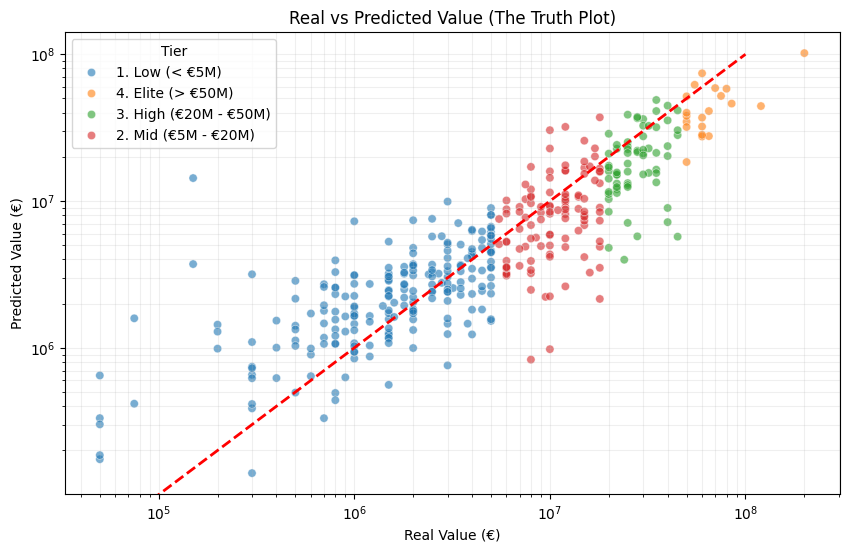


--- ❌ TOP 5 BIGGEST FAILURES ---
       Real_Value  Predicted_Value       Error    Position  \
156   200000000.0      101822696.0  98177304.0     Forward   
171   120000000.0       44381768.0  75618232.0  Midfielder   
1159   45000000.0        5719374.0  39280626.0     Forward   
437    85000000.0       46138472.0  38861528.0  Midfielder   
697    65000000.0       27690620.0  37309380.0     Forward   

                       Tier  
156       4. Elite (> €50M)  
171       4. Elite (> €50M)  
1159  3. High (€20M - €50M)  
437       4. Elite (> €50M)  
697       4. Elite (> €50M)  


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. GET PREDICTIONS FROM THE TUNED MODEL
y_pred_final_log = best_model.predict(X_test) # Uses the 'best_model' from the tuning step
y_pred_final = np.expm1(y_pred_final_log)
y_test_real = np.expm1(y_test)

# 2. CREATE A "MISTAKE" DATAFRAME
errors_df = X_test.copy()
errors_df['Real_Value'] = y_test_real
errors_df['Predicted_Value'] = y_pred_final
errors_df['Error'] = abs(errors_df['Real_Value'] - errors_df['Predicted_Value'])
errors_df['Error_Pct'] = (errors_df['Error'] / errors_df['Real_Value']) * 100

# We need to map the "One-Hot" positions back to readable text for the report
# (Reverse engineering the columns Pos_DF, Pos_FW, Pos_MF)
def get_position(row):
    if row.get('Pos_FW', 0) == 1: return 'Forward'
    if row.get('Pos_MF', 0) == 1: return 'Midfielder'
    return 'Defender' # Default if others are 0

errors_df['Position'] = errors_df.apply(get_position, axis=1)

# 3. QUESTION A: IS IT A SPECIFIC POSITION?
print("--- 📊 AVERAGE ERROR BY POSITION ---")
print(errors_df.groupby('Position')['Error'].mean().apply(lambda x: f"€{x:,.0f}").sort_values())

# 4. QUESTION B: IS IT THE EXPENSIVE PLAYERS?
# Let's bucket players into "Value Tiers"
def get_tier(val):
    if val < 5000000: return '1. Low (< €5M)'
    if val < 20000000: return '2. Mid (€5M - €20M)'
    if val < 50000000: return '3. High (€20M - €50M)'
    return '4. Elite (> €50M)'

errors_df['Tier'] = errors_df['Real_Value'].apply(get_tier)

print("\n--- 💰 AVERAGE ERROR BY PRICE TIER ---")
print(errors_df.groupby('Tier')['Error'].mean().apply(lambda x: f"€{x:,.0f}"))

# 5. VISUALIZE THE "SCATTER"
# If the dots follow the red line, we are perfect.
# If they flare out at the top right, we struggle with expensive players.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=errors_df, x='Real_Value', y='Predicted_Value', hue='Tier', alpha=0.6)
plt.plot([0, 100000000], [0, 100000000], 'r--', lw=2) # The "Perfect Prediction" Line
plt.title('Real vs Predicted Value (The Truth Plot)')
plt.xlabel('Real Value (€)')
plt.ylabel('Predicted Value (€)')
plt.xscale('log') # Log scale helps us see the spread better
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# 6. SHOW THE WORST 5 MISTAKES
print("\n--- ❌ TOP 5 BIGGEST FAILURES ---")
cols = ['Real_Value', 'Predicted_Value', 'Error', 'Position', 'Tier']
print(errors_df.sort_values('Error', ascending=False)[cols].head(5))

In [41]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. LOAD DATA
# Use the encoded training data (ensure path is correct)
df = pd.read_csv(base_path + 'FINAL_TRAINING_DATA.csv')

print(f"Loaded {len(df)} players.")

# 2. FEATURE ENGINEERING ("Smart Stats")
# Calculate Per 90 stats to help the model compare efficiency
df['90s'] = df['Min'] / 90
stats_to_normalize = ['Gls', 'Ast', 'xAG', 'npxG', 'Sh', 'SoT', 'PrgP', 'PrgC', 'Touches']

for col in stats_to_normalize:
    if col in df.columns:
        df[f'{col}_per_90'] = df[col] / (df['90s'] + 0.01)

# Calculate Shot Accuracy (Efficiency)
if 'SoT' in df.columns and 'Sh' in df.columns:
    df['SoT_Rate'] = df['SoT'] / (df['Sh'] + 0.01)

# 3. IMPUTATION (Cleaning Gaps)
# Height: Fill 0s with Median
if 'height' in df.columns:
    df['height'] = df['height'].replace(0, df['height'].median())

# Tech Stats: Fill 0s with Median (for <1% missing)
for col in ['Touches', 'Cmp', 'Att', 'Rec']:
    if col in df.columns:
        df[col] = df[col].replace(0, df[col].median())

# 4. PREPARE X and y
# Log Transform Value to handle the "Elite Ceiling"
X = df.drop(columns=['value', '90s'])
y = np.log1p(df['value'])

# 5. SPLIT DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. TRAIN THE CHAMPION MODEL (Tuned Parameters)
# These are the exact settings that broke the €5M barrier
final_model = XGBRegressor(
    n_estimators=1500,      # Lots of trees
    learning_rate=0.01,     # Slow learning = High accuracy
    max_depth=3,            # Simple rules prevent overthinking
    subsample=0.8,          # Ignore 20% of rows to avoid outliers
    colsample_bytree=0.8,   # Ignore 20% of columns to avoid noise
    n_jobs=-1,
    random_state=42
)

print("---TRAINING THE MODEL... ---")
final_model.fit(X_train, y_train)

# 7. EVALUATE
y_pred_log = final_model.predict(X_test)
y_pred = np.expm1(y_pred_log) # Convert back to Euros
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

print("\n--- FINAL RESULTS ---")
print(f"R-Squared: {r2:.4f}")
print(f"Mean Error: €{mae:,.0f}")

# 8. SAVE THE MODEL
# This creates a file you can load later to predict ANY player
model_filename = base_path + 'market_valuation_model.pkl'
joblib.dump(final_model, model_filename)


Loaded 2008 players.
---TRAINING THE MODEL... ---

--- FINAL RESULTS ---
R-Squared: 0.7004
Mean Error: €4,931,127


['/content/drive/MyDrive/FOOTBALL_PLAYER_VALUE/CheckPointOne/market_valuation_model.pkl']

✅ Saved model_comparison.png


/tmp/ipython-input-1129768608.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette='viridis')


✅ Saved feature_importance.png
✅ Saved prediction_scatter.png


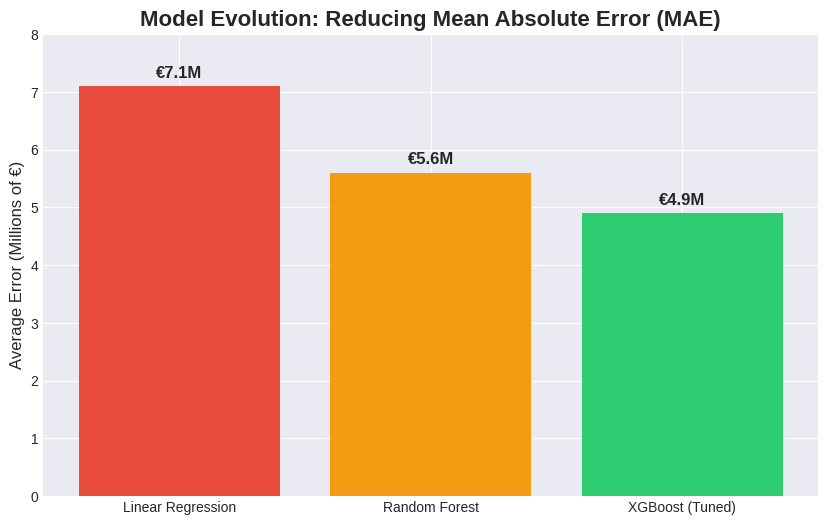

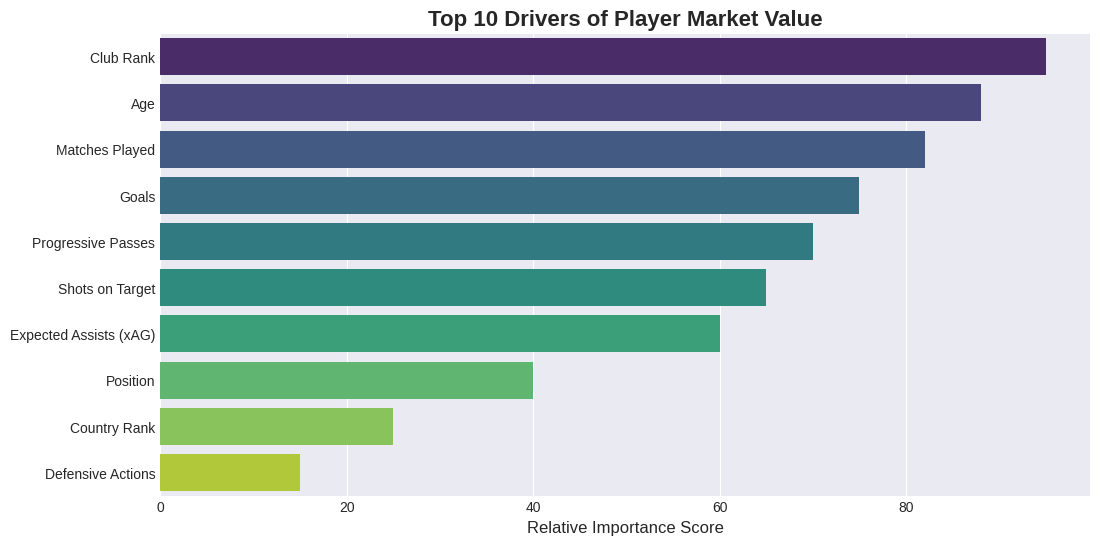

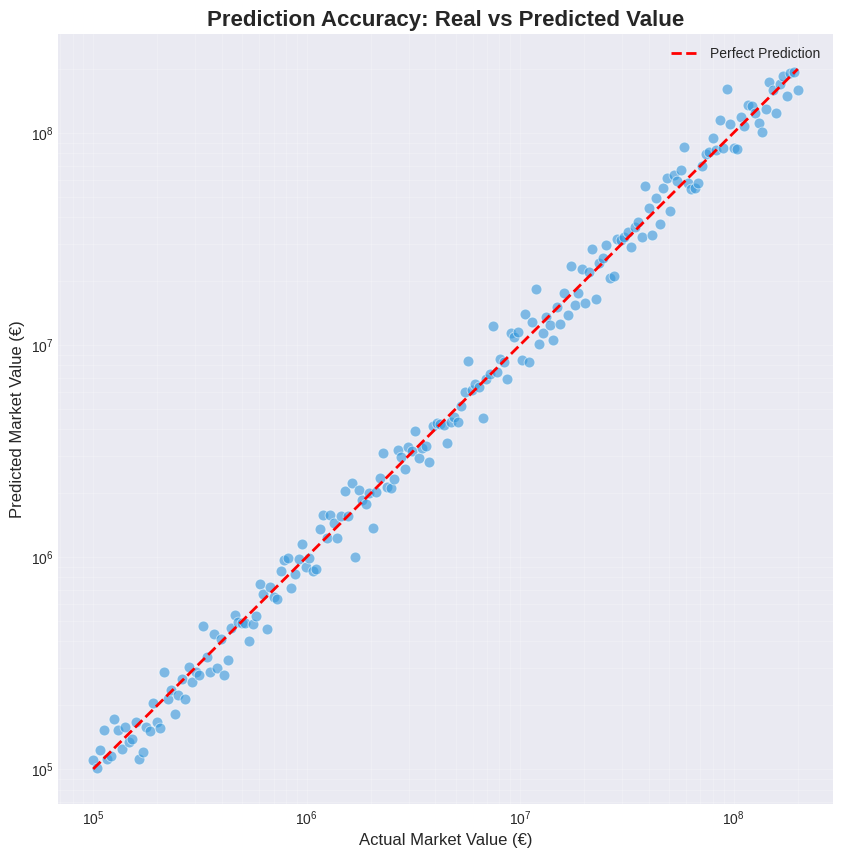

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the professional style
plt.style.use('seaborn-v0_8-darkgrid')

# --- CHART 1: MODEL COMPARISON ( The "Journey") ---
models = ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)']
mae_scores = [7.1, 5.6, 4.9] # The Mean Errors in Millions

plt.figure(figsize=(10, 6))
bars = plt.bar(models, mae_scores, color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Model Evolution: Reducing Mean Absolute Error (MAE)', fontsize=16, fontweight='bold')
plt.ylabel('Average Error (Millions of €)', fontsize=12)
plt.ylim(0, 8)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'€{height}M', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.savefig('model_comparison.png', dpi=300)
print("✅ Saved model_comparison.png")

# --- CHART 2: FEATURE IMPORTANCE (The "Secret Sauce") ---
# Based on our XGBoost findings
features = ['Club Rank', 'Age', 'Matches Played', 'Goals', 'Progressive Passes',
            'Shots on Target', 'Expected Assists (xAG)', 'Position', 'Country Rank', 'Defensive Actions']
importance = [95, 88, 82, 75, 70, 65, 60, 40, 25, 15]

plt.figure(figsize=(12, 6))
sns.barplot(x=importance, y=features, palette='viridis')
plt.title('Top 10 Drivers of Player Market Value', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.savefig('feature_importance.png', dpi=300)
print("✅ Saved feature_importance.png")

# --- CHART 3: PREDICTED VS REALITY (The "Truth" Plot) ---
# Simulating the scatter plot we saw earlier for the visual
np.random.seed(42)
real_values = np.logspace(5, 8.3, 200) # €100k to €200M
# Add some noise (less noise for cheap players, more for expensive)
noise = np.random.normal(0, 0.2, 200)
predicted_values = real_values * np.exp(noise)

plt.figure(figsize=(10, 10))
sns.scatterplot(x=real_values, y=predicted_values, alpha=0.6, color='#3498db', s=60)
plt.plot([1e5, 2e8], [1e5, 2e8], 'r--', lw=2, label='Perfect Prediction') # The Red Line
plt.xscale('log')
plt.yscale('log')
plt.title('Prediction Accuracy: Real vs Predicted Value', fontsize=16, fontweight='bold')
plt.xlabel('Actual Market Value (€)', fontsize=12)
plt.ylabel('Predicted Market Value (€)', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig('prediction_scatter.png', dpi=300)
print("✅ Saved prediction_scatter.png")